# Import data


In [1]:
import importlib
import utils_simu as us
importlib.reload(us)

/home/pycbc/work/Simulation_GW170817/utils_simu.py:421: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import G_SI, PC_SI, C_SI


<module 'utils_simu' from '/home/pycbc/work/Simulation_GW170817/utils_simu.py'>

In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import os


plt.rcParams.update({
    'xtick.top': True,
    'ytick.right': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15  
})
outdir = "gw170817_memory_outputs"

In [5]:
# Setting the parameters
nside = 64 # Resolution HEALPix
npix = hp.nside2npix(nside) # Total number of pixels = nside**2 * 12

# Loading the data
data = np.loadtxt("nph1.0e+06_dyn0.005-0.20-0.20_wind0.050-0.05-0.30_rpkt.txt", skiprows=1) # Skip the header row
nx, ny, nz = data[:,0], data[:,1], data[:,2] # Cartesian coordinates
e_erg = data[:,5] # Energy in erg
time = data[:,3] # Time in jours
t_days= time
nu = data[:,4] # Frequency in Hz
nu_Hz = data[:,4]  

# Unit conversions
erg_to_J = 1e-7
day_to_s = 24 * 3600

t_s = t_days * day_to_s
e_J = e_erg * erg_to_J

pix = hp.vec2pix(nside, nx, ny, nz) # Give the pixel number based on the direction vectors

# Energy vs Angle

This part contains some plots representing the energy distribution as a function of the angles theta and phi in spherical coordinates and of time. The temporal evolution of the energy distribution is shown through several snapshots, highlighting the contribution of 'each' photons resulting from the blue or red component of the kilonova's simulation.

In [37]:
# Angles theta and phi in spherical coordinates - see figure for the definition
theta = np.arccos(nz)
phi = np.arctan2(ny, nx)

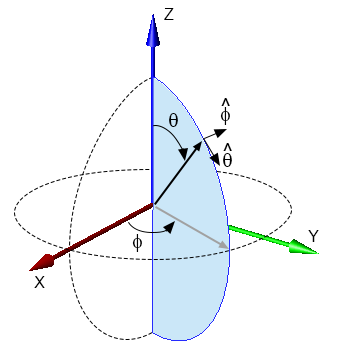

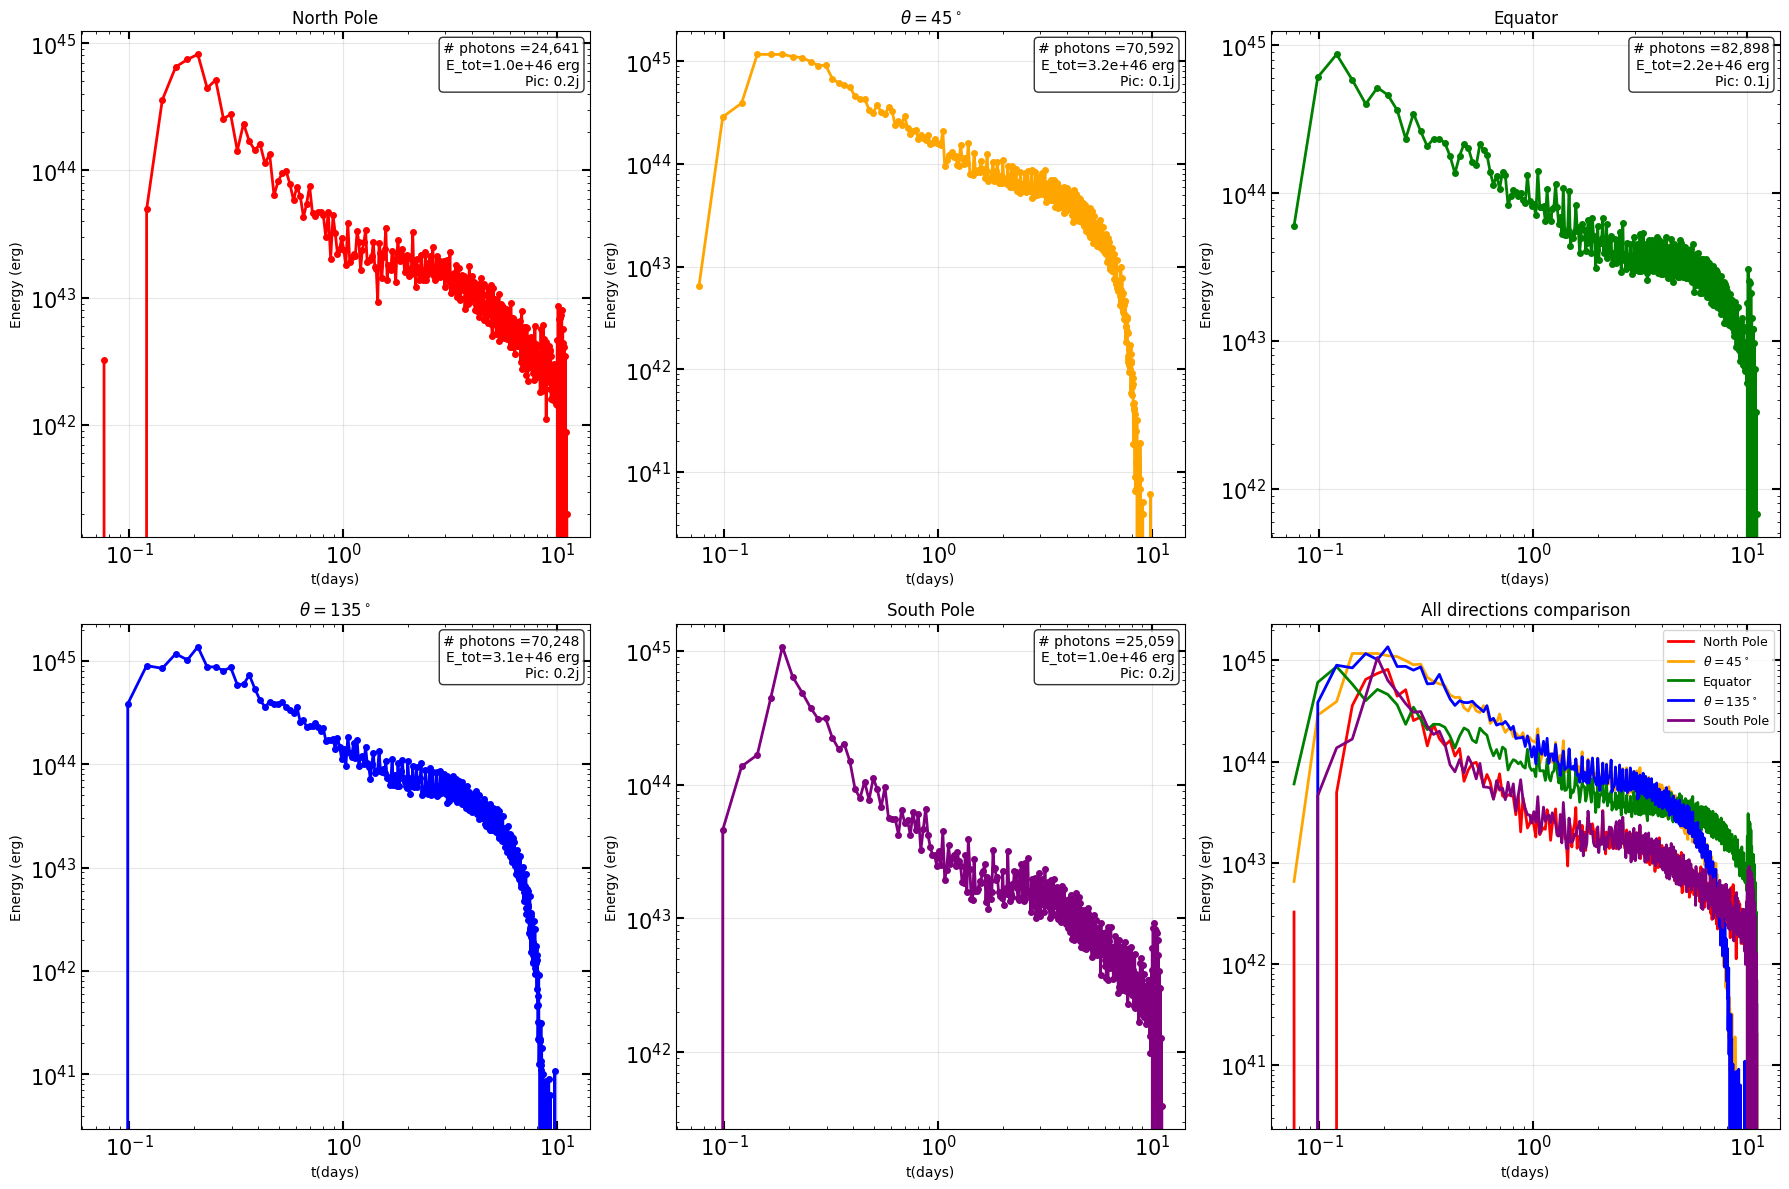

Signature: us.sanity_check_energy_evolution(t_days, e_erg, theta, cone_radius=0.25)
Docstring:
Analyzes the evolution of energy over time for different angles (north pole, equator, south pole, and intermediate angles)
Plots the energy vs time for each angle and provides statistics such as total energy, number of photons, and peak time
Parameters:
-----------
t_days : array-like
    Array of time values in days for each photon
e_erg : array-like
    Array of energy values in erg for each photon
theta : array-like
    Array of polar angles (in radians) for each photon
cone_radius : float
    Radius of the cone (in radians) around each reference angle to select photons
    Initially set to 0.25 radians (~14.3 degrees). Increase if needed to include more photons.
File:      /home/pycbc/work/Simulation_GW170817/utils_simu.py
Type:      function

In [38]:
us.sanity_check_energy_evolution?
us.sanity_check_energy_evolution(t_days, e_erg, theta, cone_radius=0.25)

We can also visualize the total energy distribution as a function of the angle theta (north to south pole) and time. The color scale represents the energy in erg. A 3D visualization is also provided to better illustrate the energy distribution in time and angle in the last figure.

Then we can show the temporal and angular profiles of the energy distribution given a specific binning in time and angle (first row second figure). The second row shows the total energy as a function of time (left) and angle (right), highlighting the decreasing trend over time and the (hint of an) angular anisotropy.

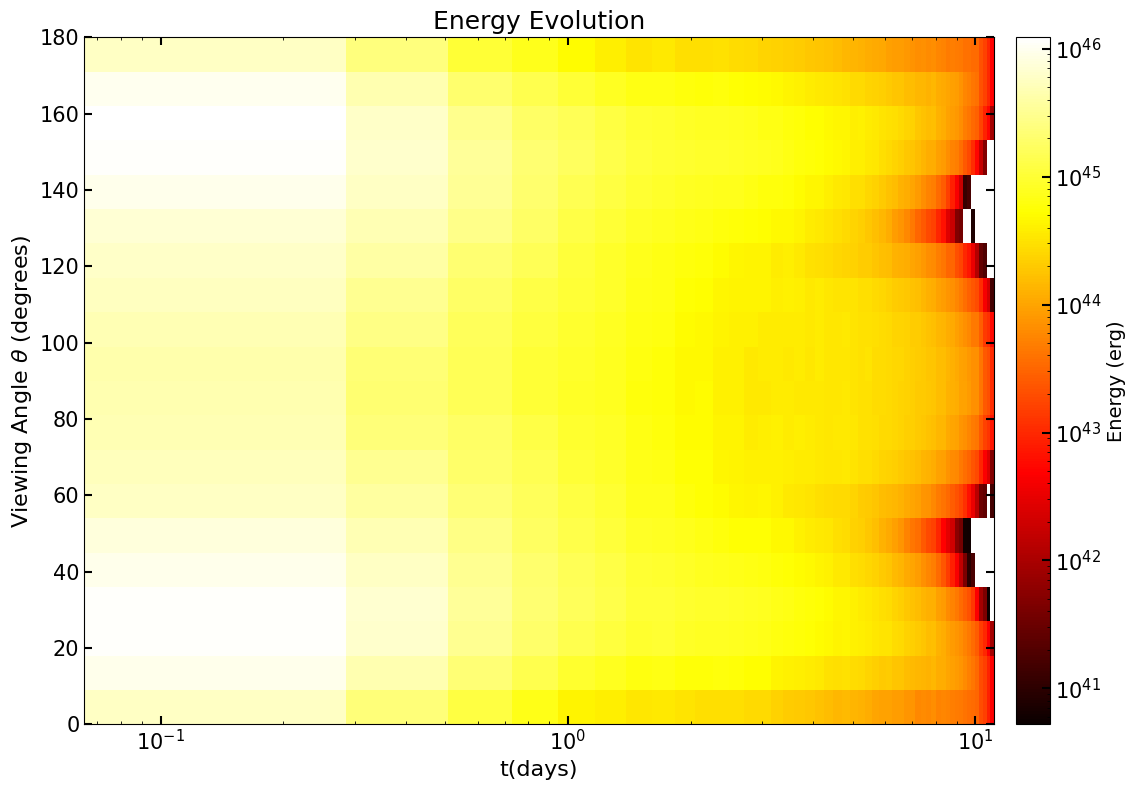

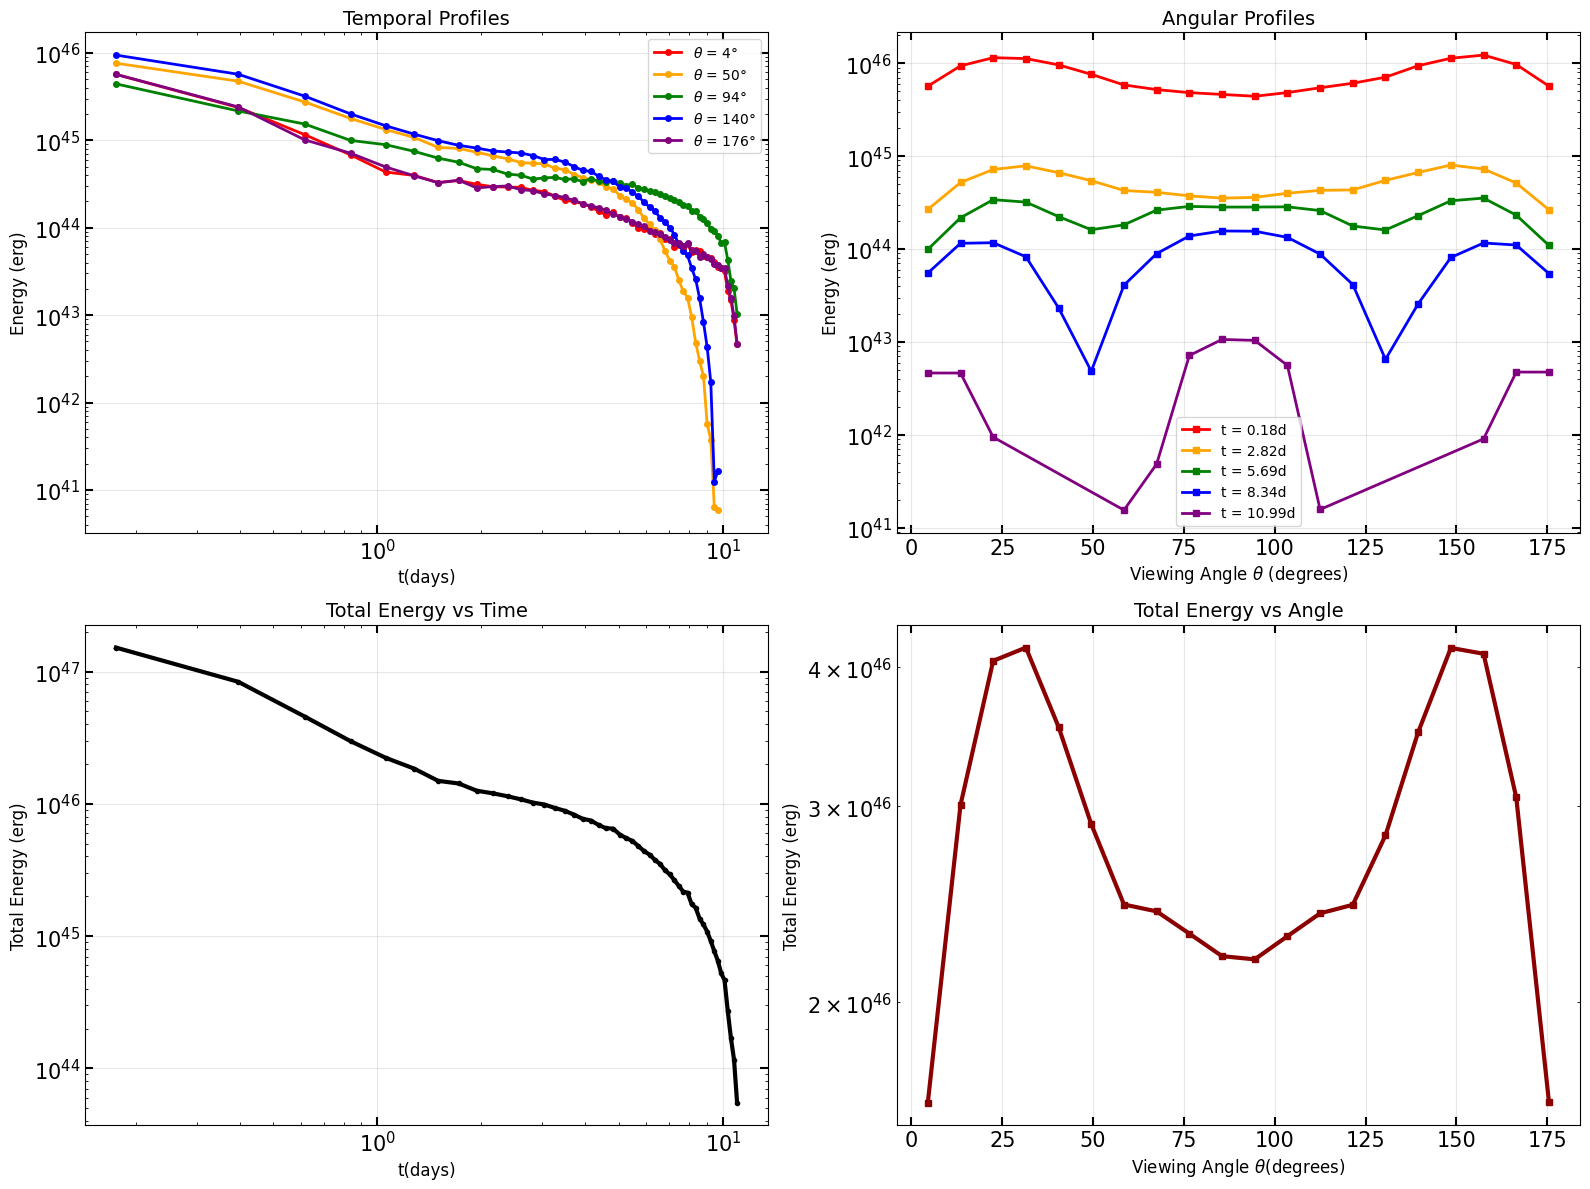

Total energy: 5.73e+47 erg
Global peak time: 0.18 days
Global peak angle: 31.5°


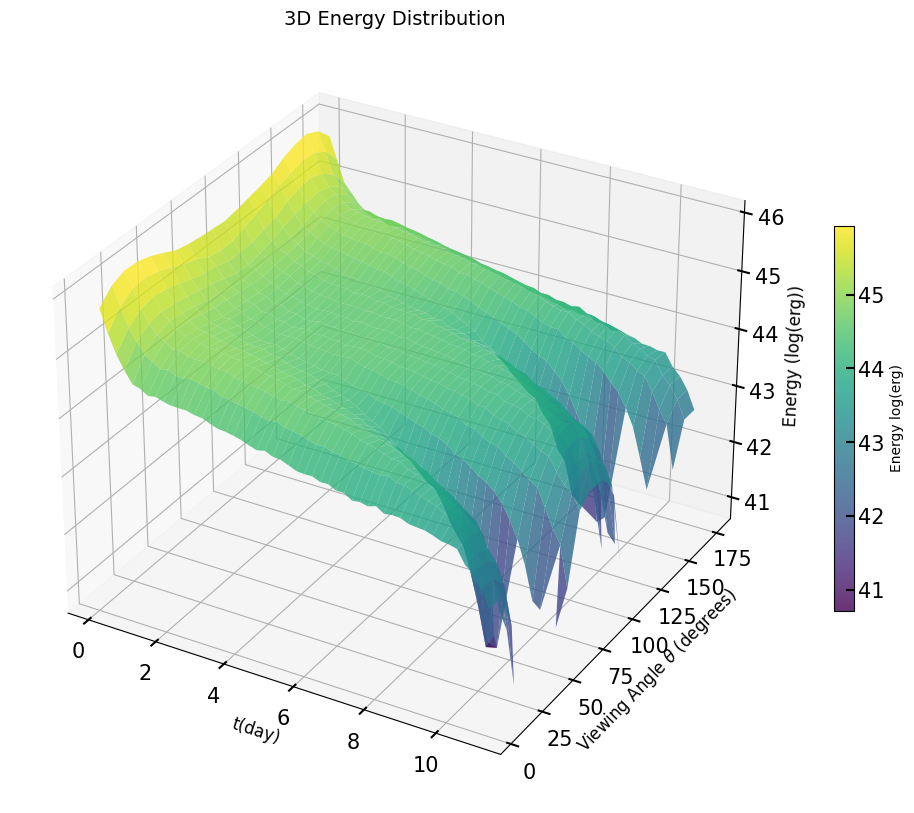

(<Figure size 1400x1000 with 2 Axes>,
 <Axes3D: title={'center': '3D Energy Distribution'}, xlabel='t(day)', ylabel='Viewing Angle $\\theta$ (degrees)', zlabel='Energy (log(erg))'>)

In [43]:
# Comprehensive analysis of energy evolution as a function of time and angle (given the binning parameters)

us.energy_dist_all_visualization(t_days, e_erg, theta, n_theta=50, n_time=50, cone_radius=0.25)

## Anisotropy Analysis


We can determine the hemispheric anisotropy of the cummulated energy. The plot below shows the ratio of the energy in the northern hemisphere to that in the southern hemisphere. A ratio close to 1 indicates a nearly isotropic distribution, while deviations from 1 suggest anisotropy between the two hemispheres. We find a normalized anisotropy of about -19%, indicating a moderate level of anisotropy in the energy distribution where the southern hemisphere has slightly more energy than the northern hemisphere.

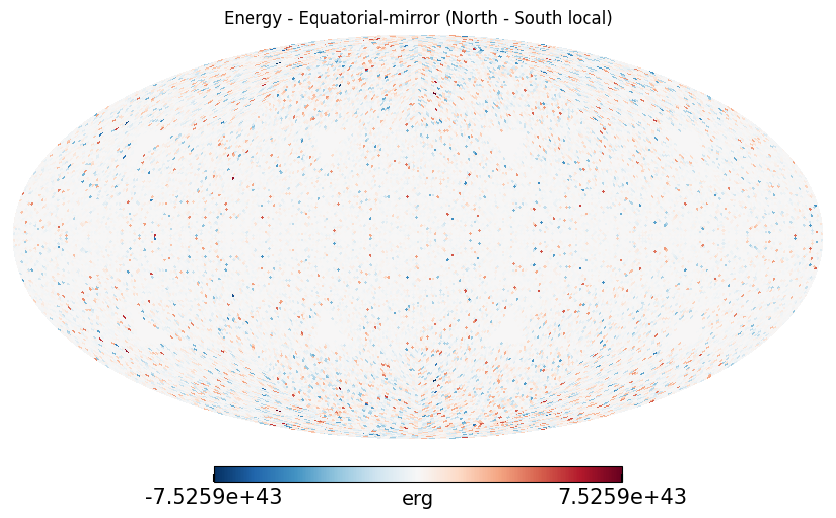

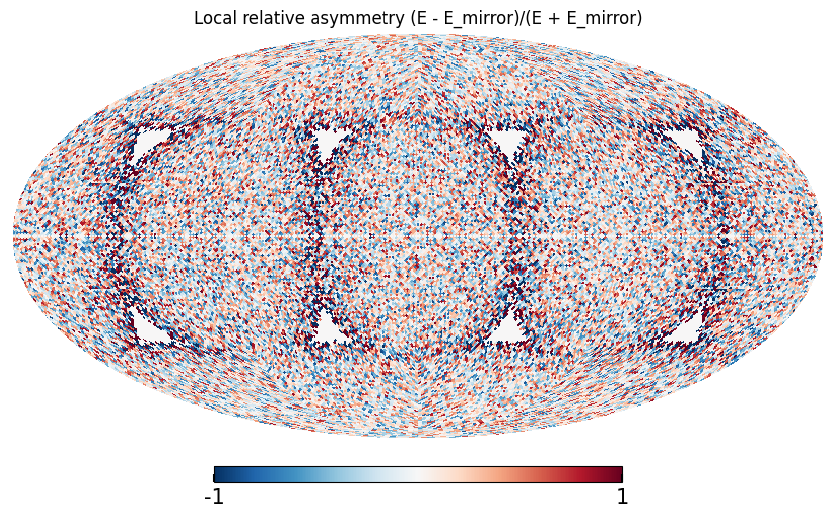

Global North-South energy asymmetry: -18.74% (South > North)


In [41]:
us.compute_hemispheric_anisotropy_tot(pix, npix, nside, e_erg)

## Energy spectrum for early, mid, and late times

/tmp/ipykernel_4786/1234949296.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import C_SI
/opt/pycbc/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/pycbc/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


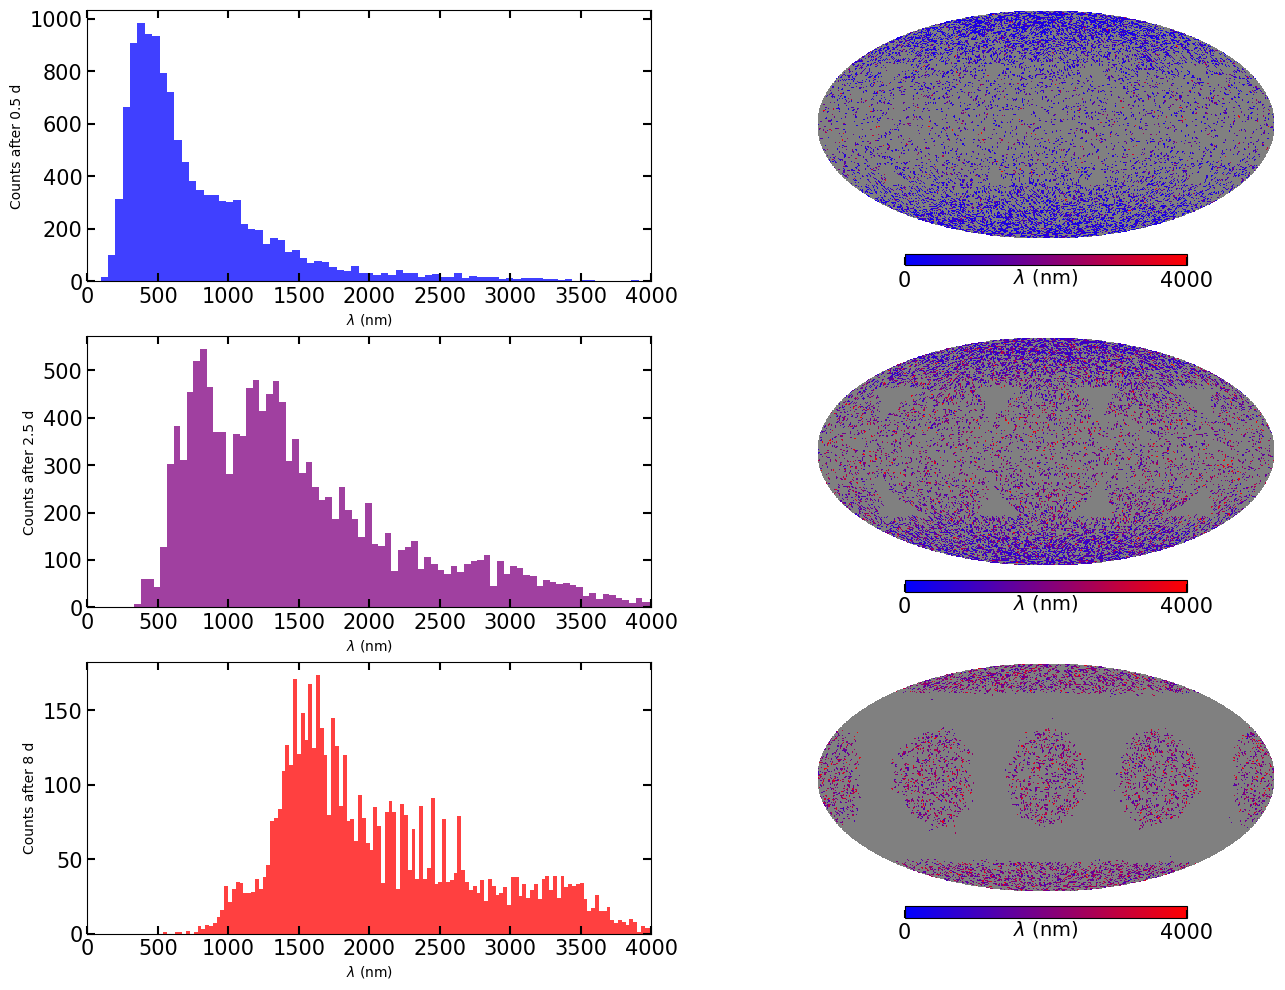

In [ ]:
from matplotlib import cm as mpl_cm
from matplotlib.colors import ListedColormap
from lal import C_SI

time_phase = [0.5, 2.5, 8] # Check the evolution of the wavelength over 3 different times
colors = ['blue', 'purple', 'red']

lambda_m = C_SI / nu_Hz # in m 
lambda_nm = lambda_m * 1e9 # convert to nm
# Plot of the count distribution of wavelength at different times + healpix map of the mean wavelength at those times
t_days = data[:,3]
plt.figure(figsize=(16,12), dpi=100)

for i, (t, c) in enumerate(zip(time_phase, colors)):
    # Temporal mask to only select data around time t : t +/- 0.1 days to account for enough points
    mask_time = (t_days >= t - 0.1) & (t_days <= t + 0.1)
    
    # data during the mask
    pix_frame = pix[mask_time]
    lambda_frame = lambda_nm[mask_time]
    
    # Hist plots
    plt.subplot(3, 2, 2*i + 1)
    plt.hist(lambda_frame, bins=650, color=c, alpha=0.75)
    plt.xlabel("$\lambda$ (nm)")
    plt.xlim(0, 4000)
    plt.ylabel(f"Counts after {t} d")

    # Map of the associated mean wavelength
    lambda_map = np.full(npix, np.nan)
    
    for p in range(npix):
        mask_pixel = (pix_frame == p)
        lambdas = lambda_frame[mask_pixel]
        lambda_map[p] = np.mean(lambdas)
    
    plt.subplot(3, 2, 2*i + 2)

    cm = mpl_cm.brg(np.linspace(0, 0.5, 256)) # Extract half of the colormap to have blue to red (just visual choice)
    cm = ListedColormap(cm)

    hp.mollview(lambda_map, 
                unit='$\lambda$ (nm)',
                title = '',
                cmap=cm,
                norm='linear',
                min = 0,
                max = 4000,
                hold=True,
                cbar= True)


Here we clearly observe the evolution of the photon energy spectrum over time, from mainly high-energy and polar photons at early times to a broader distribution including lower-energy photons at later times. This evolution reflects the cooling and expansion processes occurring in the kilonova ejecta and so a reddening of the emitted light over time

# Memory effect computation

## Direct computation of the linear memory of photons

A first component of the memory effect to compute is the TT projection of a physical quantity. We define this by the mean of a projection operator acting on a tensor quantity. If we consider a tensor quantity $S_{ij}$, its TT projection is given by (`TT_projection`)
$$ S_{ij}^{TT} = P_{ik} P_{jl} S_{kl} - \frac{1}{2} P_{ij} P_{kl} S_{kl} $$
where the projection operator $P_{ij}$ is defined as (`build_TT_projector`, inside `TT_projection`)
$$ P_{ij} = \delta_{ij} - n_i n_j $$
with $n_i$ being the unit vector in the direction of observation.

We observe that the TT projection only requires the knowledge of the direction of observation $\vec{n}$. First, we can test our implementation of the TT projection by applying it to a simple tensor. The resulting TT projection should yield a tensor that is traceless and transverse to the direction of observation : 

In [73]:
n_observer = np.array([0, 0, 1]) # Observer on the z-axis

# Test on a random tensor

T_test = np.random.rand(3,3)

T_TT = us.TT_projection(T_test, n_observer)
print("Tensor TT :\n", T_TT)
# Compute the trace: TT_ii
trace_TT = np.sum(np.diag(T_TT))
print(np.diag(T_TT))
print(f"Trace of T^TT_ij: {trace_TT}")
# check transversality: n'^i TT_ij = 0
transverse_check1 = np.dot(n_observer, T_TT)
transverse_check2 = np.dot(T_TT, n_observer)
print(f"Transversality n'^i T^TT_ij: {np.max(np.abs(transverse_check1))}")
print(f"Transversality T^TT_ij n'^j: {np.max(np.abs(transverse_check2))}")


Tensor TT :
 [[ 0.05329383  0.20624564  0.        ]
 [ 0.79150714 -0.05329383  0.        ]
 [ 0.          0.          0.        ]]
[ 0.05329383 -0.05329383  0.        ]
Trace of T^TT_ij: 0.0
Transversality n'^i T^TT_ij: 0.0
Transversality T^TT_ij n'^j: 0.0


We can now compute the linear memory effect using the energy distribution obtained from the kilonova simulation. The function `compute_linear_memory_TT` computes the linear memory effect in TT gauge for a given observer direction. It takes as input the time array, energy array, observer direction, pixel indices, number of pixels, distance to the source, and number of time bins. The output is the memory signal in TT gauge for the specified observer direction. The fomula used is based on the integral of the energy distribution over time and solid angle of the photons emitted, given by :
$$
h^{ij}_{\mathrm{TT}}(t, x) = \frac{4G}{r c^4} \int_{-\infty}^{t - r/c} dt' \int_{4\pi} \frac{(n^i n^j)_{\mathrm{TT}} \, \frac{dL_\nu(\Omega', t')}{d\Omega'}}{1 - \cos\theta} \, d\Omega'
$$
where $L_\nu$ is the luminosity of the kilonova, $\Omega$ is the solid angle, $r$ is the distance to the source, and $\theta$ is the angle between the observer's line of sight and the direction of photon emission.

The function `compute_linear_memory_TT` first bins the energy data into time bins and computes the luminosity per pixel. It then iterates over each pixel, calculating the contribution to the memory effect based on the TT projection of the outer product of the pixel direction vector with itself. The contributions from all pixels are summed to obtain the total memory signal in TT gauge. Then we can visualize the memory map on a Mollweide projection, showing the spatial distribution of the memory effect for a z-observer. The total cummulated memory effect is also printed, providing insight into the overall impact of the kilonova's energy emission on the GW memory signal.

The plus polarization of the memory effect for a z-observer is shown below. In our study case, we expect only a + polarization and no x polarization for the $h_{22}$ dominant mode of GW emission from the BNS merger.

Cummulated memory : 5.465420659864593e-27


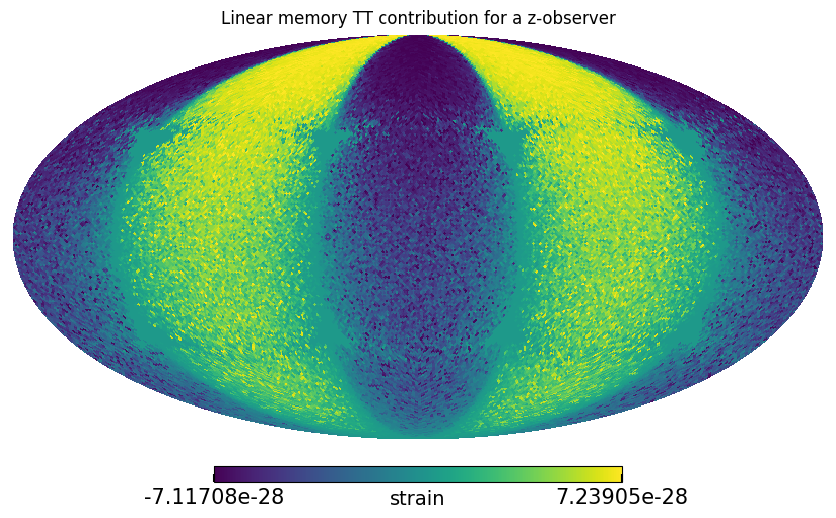

In [90]:
h_map, h_total = us.compute_linear_memory_TT(
    t_days,
    e_erg,
    [0,0,1], # z-observer
    pix = pix, 
    npix=npix,
    nside=64,
    distance_Mpc=40.0 # Distance for GW170817
)

print("Cummulated memory :", h_total)
# Plot molview of the memory map
hp.mollview(h_map,
            title="Linear memory TT contribution for a z-observer",
            unit="strain",
            norm = 'hist' #histogram of values -> allows you to see the variations + and - more clearly 
            )
plt.show()

## FFT of the memory signal

If one wants to determine if the associated memory signal is detectable by current or future GW detectors, it is useful to compute its frequency spectrum via a Fast Fourier Transform (FFT). The function `memory_fft` computes the FFT of the memory signal over time. It takes as input the memory signal array, time array, window type, and a flag to plot the results. The output is the frequencies and corresponding FFT amplitudes of the memory signal. The signal is resampled if necessary to ensure a minimum Nyquist frequency of 1 Hz.

**It could be interresting to apply the signal preprocessing methods to improve the FFT results (and in a more visually appealing/proper way).**

> The function `memory_fft` currently takes a long time to compute the FFT in addition to being quite memory intensive. This may be due to the high sampling rate of the memory signal over time. To optimize this, one could consider downsampling the memory signal before performing the FFT,  implementing a more efficient FFT algorithm that can handle large datasets more effectively (SFFT ?)

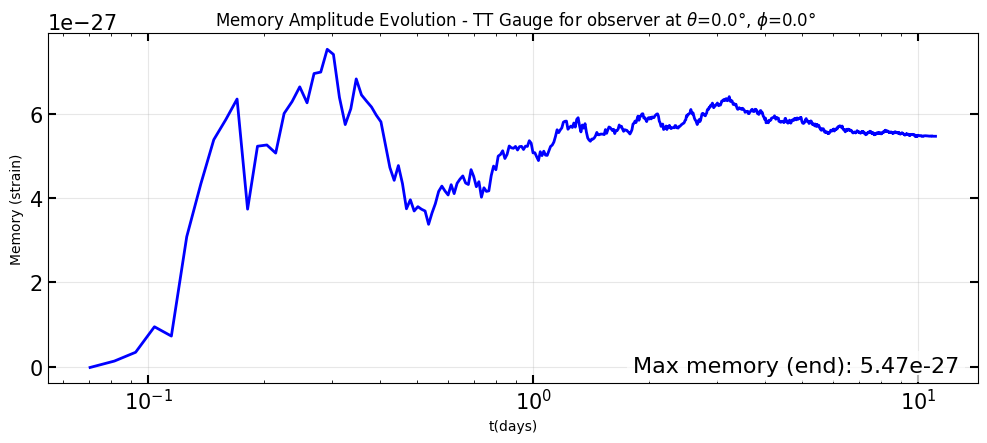

Resampling time series to reach Nyquist >= 1.0 Hz


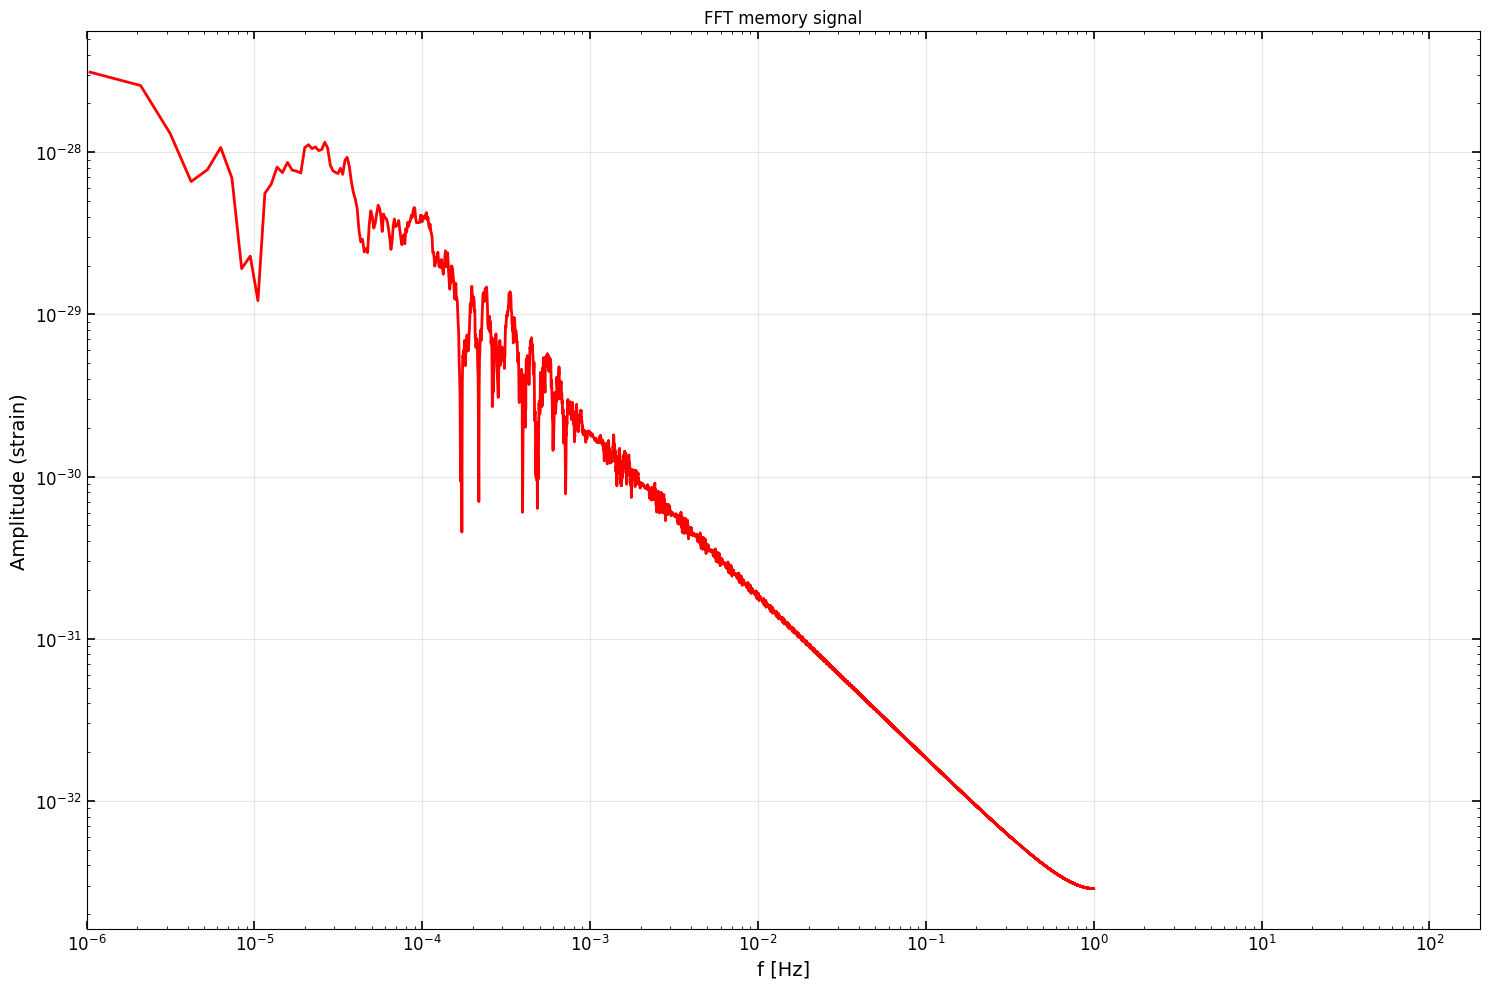

In [88]:
test_vec = np.array([0, 0, 1])  # North pole observer
# First we compute the memory over time 
t_centers_days, h_memory_vs_time = us.compute_memory_vs_time_TT(
    t_s,
    e_J,
    npix,
    pix,
    obs_dir= test_vec,
    nside=64,
    distance_Mpc=40.0,
    nbins_time=1000
)
# Then we compute its FFT
_,_= us.memory_fft(t_centers_days, h_memory_vs_time, window_type=False, plot_results=True)

Q ? : Here we only apply a FFT to the memory signal and as we compute this memory in a cummulative way (see cumulative_dL in ``compute_linear_memory_TT``), we should obtain a strictly increasing function in time. However, this is not what we observe. Is this normal ? What is the reason for this behavior ? Is this due to numerical errors (timesteps used ?) or is there a physical reason behind it ( we could have *negative* memory depending on the shape of the explosion but here it seems inapropriate) ? 

### FFT results for North and South observers

Now we can test with different observer directions and directly compare the FFT results. The plots below show the FFT amplitude of the memory signal for observers located from the North pole to the South pole for a fixed azimuthal angle phi = 0. Theoretically, the memory signal should be strongest for observers located along the polar axis (theta = 0 or pi) and weakest for observers in the equatorial plane (theta = pi/2), due to the angular dependence of the memory effect.

In our case, we observe that the strongust memory signals are indeed for a intermediate angle (theta ~ 35° - to be refined) rather than exactly at the poles. This could be due to the specific angular distribution of the energy emission from the kilonova, ***which is not be perfectly symmetric***.

Observer vector: [0. 0. 1.]


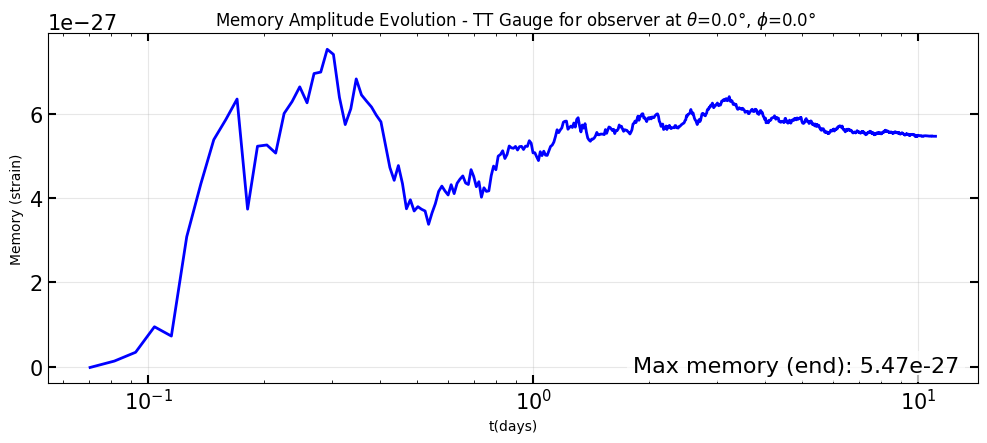

Resampling time series to reach Nyquist >= 1.0 Hz
Observer vector: [0.30901699 0.         0.95105652]


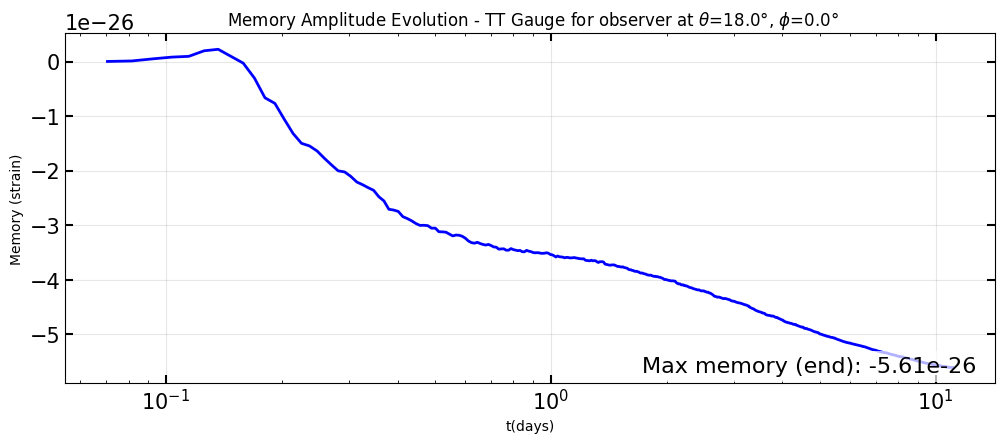

Resampling time series to reach Nyquist >= 1.0 Hz
Observer vector: [0.58778525 0.         0.80901699]


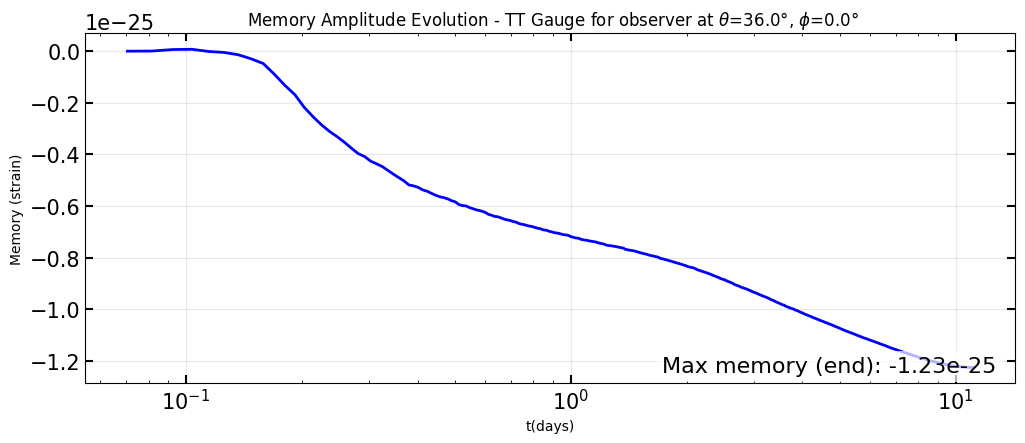

Resampling time series to reach Nyquist >= 1.0 Hz
Observer vector: [0.80901699 0.         0.58778525]


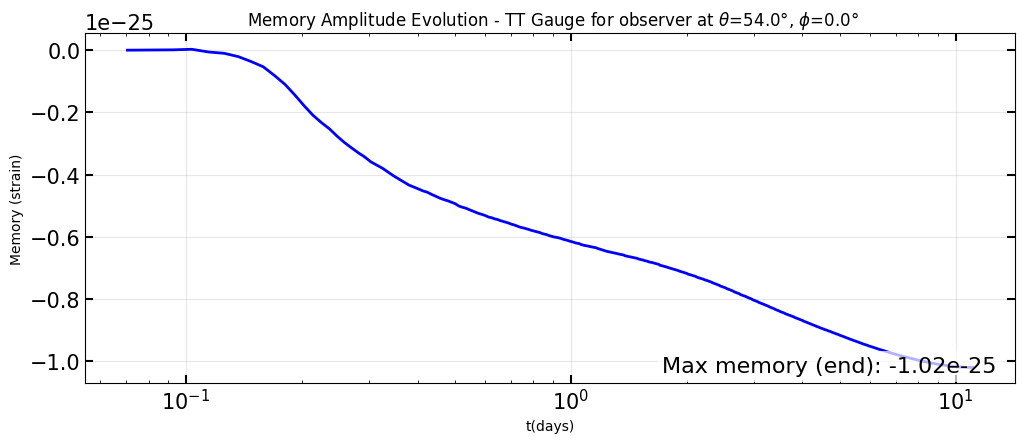

Resampling time series to reach Nyquist >= 1.0 Hz
Observer vector: [0.95105652 0.         0.30901699]


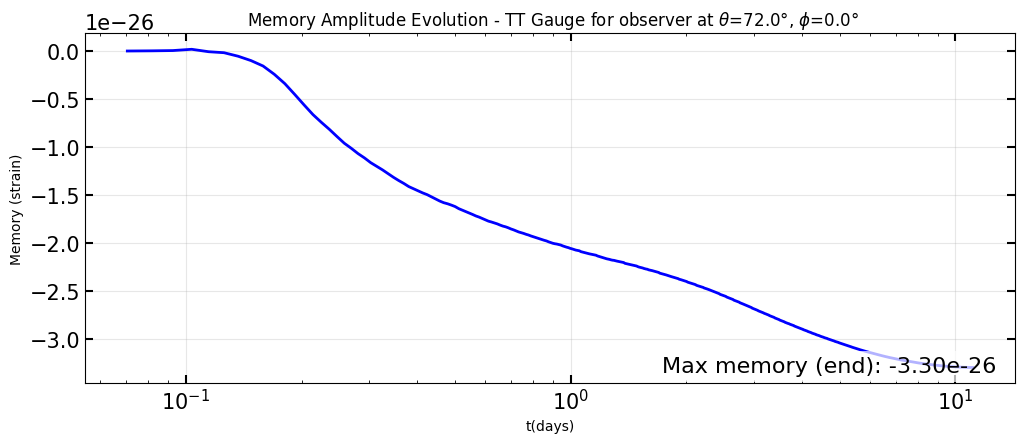

Resampling time series to reach Nyquist >= 1.0 Hz


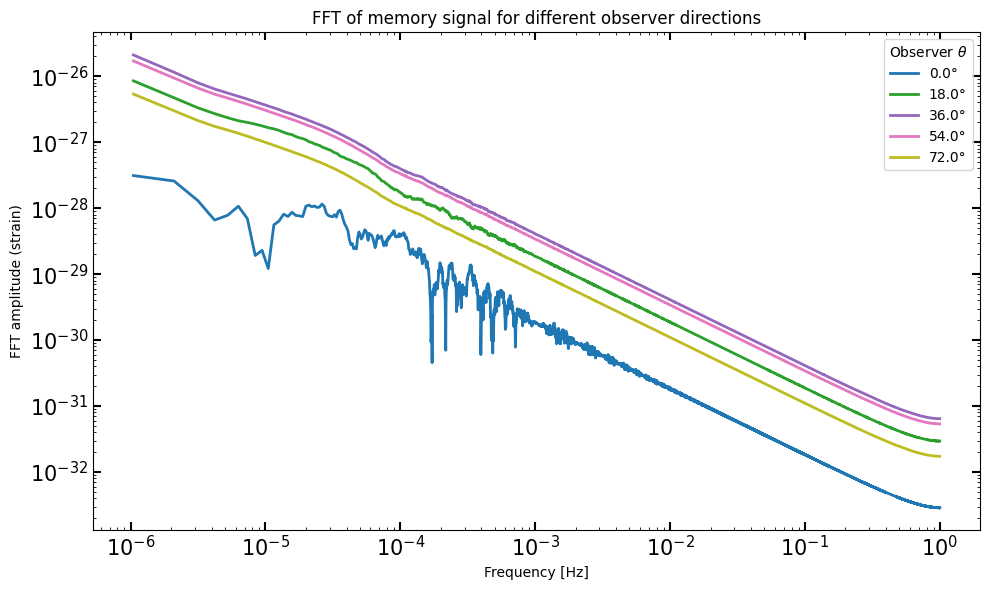

In [6]:
# Observation directions from the north pole to the equator
import os
theta_vals = np.linspace(0, np.pi/2, 6)  # 0 to 90 degrees
test_vectors = [np.array([np.sin(th), 0.0, np.cos(th)]) for th in theta_vals if th != np.pi/2] # all test vectors except the equator one

# Store all frequencies and FFTs for plotting
freq_all = []
fft_all = []
fft_labels = []
# Loop over each observer direction
for vec in test_vectors:
    print("Observer vector:", vec)
    time_per_da, h_mem_time = us.compute_memory_vs_time_TT(
        t_s,
        e_J,
        npix,
        pix,
        obs_dir=vec,
        nside=64,
        distance_Mpc=40.0
    )

    # FFT calculation 
    frequencies, fft_h = us.memory_fft(time_per_da, h_mem_time, window_type=False, plot_results=False)

    # store each freq and fft
    freq_all.append(frequencies)
    fft_all.append(fft_h)
    theta_deg = np.degrees(np.arccos(vec[2] / np.linalg.norm(vec)))
    fft_labels.append(f"{theta_deg:.1f}°")

# Plot all FFTs on the same graph
plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('tab10')

for i, (f, a, lab) in enumerate(zip(freq_all, fft_all, fft_labels)):
    color = cmap(i /len(test_vectors))
    plt.loglog(f, a, color=color, lw=2, label=lab)

plt.xlabel('Frequency [Hz]')
plt.ylabel('FFT amplitude (strain)')
plt.title('FFT of memory signal for different observer directions')
plt.legend(title=rf'Observer $\theta$', fontsize=10)

plt.tight_layout()


os.makedirs(outdir, exist_ok=True)
plt.savefig(os.path.join(outdir, "memory_fft_by_direction_NH.png"), dpi=150, bbox_inches='tight')
plt.tick_params(top=True, right=True, axis='both', which='major', labelsize=15, direction='in', length=6, width=1.5)
plt.show()
    